# Assignment No1

In [1]:
from pathlib import Path

from amoc_analysis import data, plotting
from amoc_analysis.spectra_filtering import analysis,spectra,filters
from amocatlas import read

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

## Read and Filter the data

In [2]:
ds=read.wh41n()

Loading 1 Willis & Hobbs 41°N dataset(s):
  0. hobbs_willis_amoc41N_tseries.txt: Transport time series of Ekman volume, Northward geostrophc, Meridional Overturning volume and Meridional Overturning Heat



In [3]:
MOC=ds["MOC"]
filtred_MOC=filters.tukey_lowpass(ds["MOC"],12,True)

## Plot timeseries and histogram

In [4]:
plt.rcParams.update({"font.size":14})

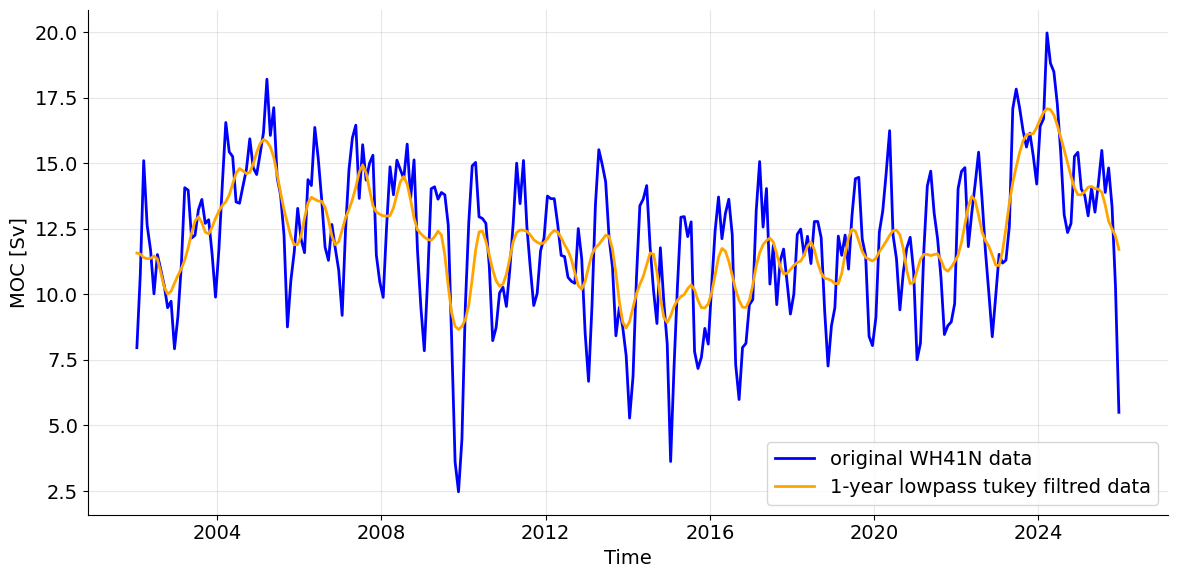

In [16]:
fig,ax=plotting.plot_time_series(ds,"MOC",label="original WH41N data", linewidth=2.0)

ax.plot(ds.TIME, filtred_MOC, color="orange", linewidth=2.0,label="1-year lowpass tukey filtred data")
ax.set_ylabel("MOC [Sv]")

plt.legend()

plt.title("")
plt.tight_layout()
plt.savefig(r"..\figures\wh41n_timeseries.png")

In [6]:
plt.rcParams.update({"font.size":10})

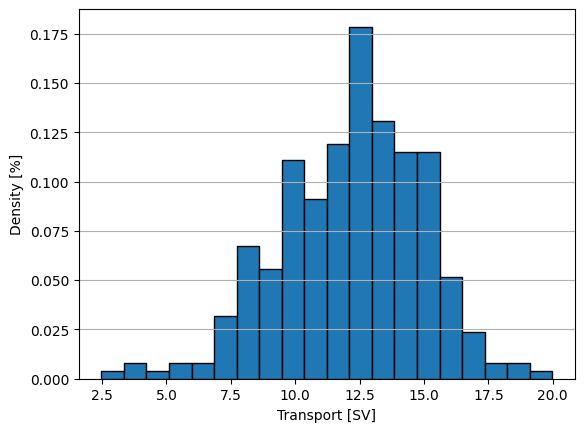

In [7]:
plt.hist(MOC,bins=20,density=True,histtype="bar",linestyle="-",edgecolor="black")
plt.xlabel("Transport [SV]")
plt.ylabel("Density [%]")
plt.grid(axis="y")


## Statistical values of MOC

In [8]:
analysis.summary_stats(MOC)

{'n': 288,
 'n_missing': 0,
 'mean': 12.135603915625,
 'std': 2.811908456102489,
 'median': 12.271187,
 'min': 2.4702439,
 'max': 19.97875,
 'range': 17.5085061}

## Calculate and plot spectra

In [9]:
plt.rcParams.update({"font.size":10})

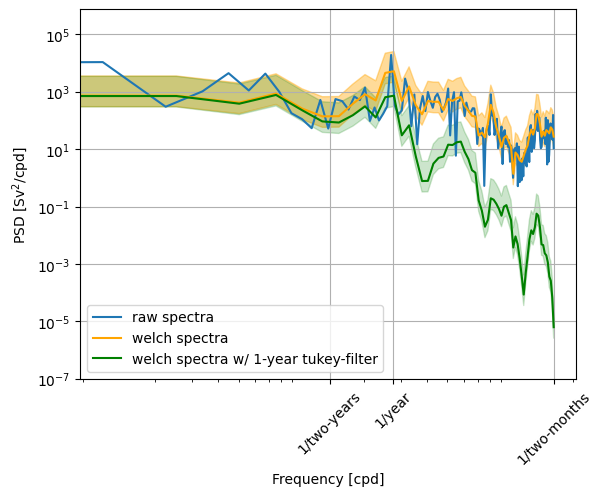

In [10]:
f,psd=spectra.raw_periodogram(MOC,31)
fw,psdw,lo,hi=spectra.welch_psd(MOC,31,128,confint=True)
fwf,psdwf,lof,hif=spectra.welch_psd(filtred_MOC,31,128,confint=True)

periods = {
        "1/day":    1 / 1,
        "1/week":   1 / 7,
        "1/month":  1 / 30,
        "1/year":   1 / 365,
    }


plt.loglog(f,psd,label="raw spectra")
plt.loglog(fw,psdw,label="welch spectra",c="orange")
plt.fill_between(fw,psdw*lo,psdw*hi,alpha=0.4,color="orange")
plt.loglog(fwf,psdwf,label="welch spectra w/ 1-year tukey-filter",c="green")
plt.fill_between(fwf,psdwf*lof,psdwf*hif,alpha=0.2,color="green")
plt.xticks([1/730, 1/365, 1/62,],["1/two-years","1/year", "1/two-months"],rotation=45)
plt.grid(True)
plt.xlabel("Frequency [cpd]")
plt.ylabel("PSD [Sv$^2$/cpd]")
plt.ylim(10e-8)
plt.legend()
plt.show()

## Investigate filter

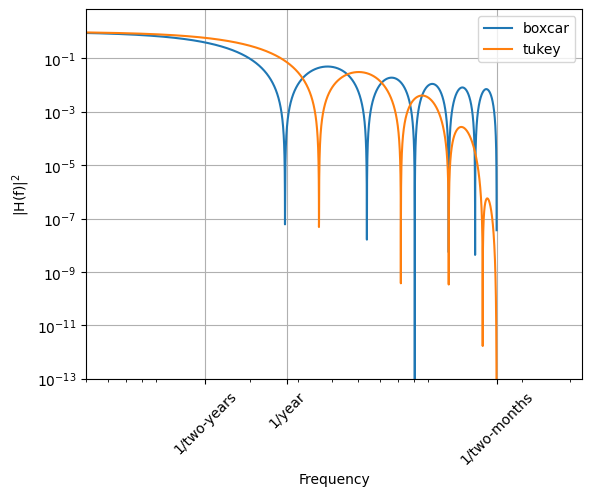

In [11]:
fig,ax=filters.window_frequency_response(12,31,("boxcar","tukey"))
ax.set_xticks([1/730, 1/365, 1/62,],)
ax.set_xticklabels(["1/two-years","1/year", "1/two-months"],rotation=45)
ax.set_xlim(1/2000,1/30)
ax.set_ylim(10e-14)
ax.set_xlabel("Frequency")
ax.set_ylabel("|H(f)|$^2$")
ax.grid()

In [12]:
plt.rcParams.update({"font.size":14})

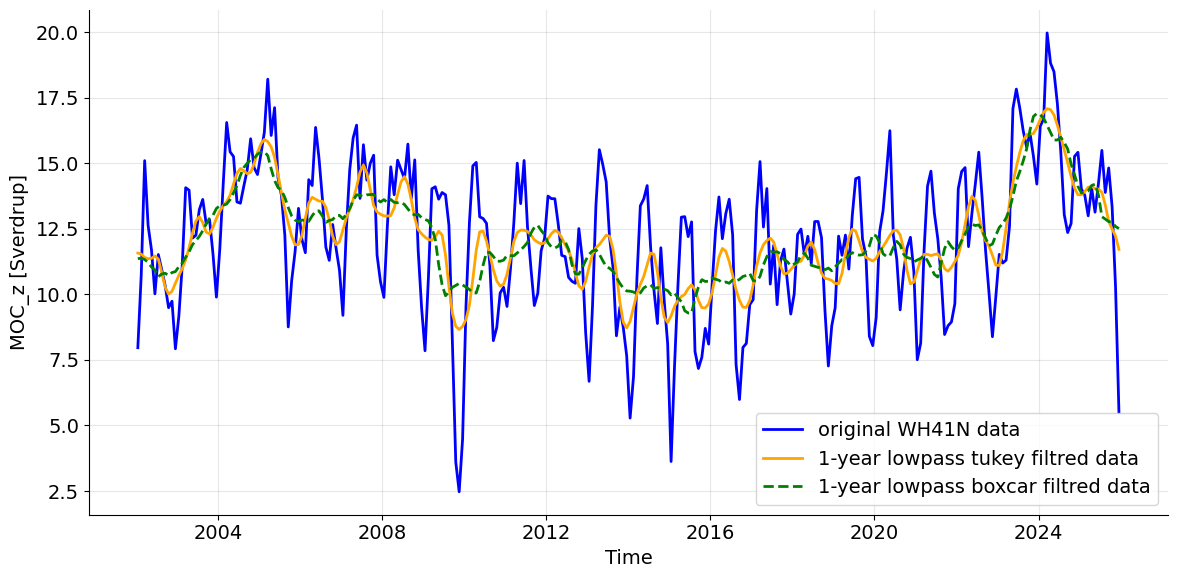

In [13]:
s = pd.Series(np.asarray(MOC, dtype="float64"))
boxcar_filtred_MOC=s.rolling(12, center=True, win_type="boxcar", min_periods=1).mean()
fig,ax=plotting.plot_time_series(ds,"MOC",label="original WH41N data",linewidth=2.0)

ax.plot(ds.TIME, filtred_MOC, color="orange", linewidth=2.0,label="1-year lowpass tukey filtred data")
ax.plot(ds.TIME, boxcar_filtred_MOC, "--g", linewidth=2.0,label="1-year lowpass boxcar filtred data")

plt.legend()

plt.title("")
plt.tight_layout()
